Notebook started: 2026-04-23 20:43
Yield records loaded: 3 plot-seasons

Plots: 1
Seasons: 3
Date range: 2023-03-15 to 2024-08-05

Yield statistics (kg/ha):
count       3.000000
mean     2833.333333
std       763.762616
min      2000.000000
25%      2500.000000
50%      3000.000000
75%      3250.000000
max      3500.000000
Name: yield_kg_ha, dtype: float64

First few records:
Rainfall records loaded: 731 daily observations

Date range: 2023-01-01 to 2024-12-31
Plots covered: 1

Rainfall statistics (mm):
count    731.000000
mean       3.414307
std        9.933222
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      115.247700
Name: rainfall_mm, dtype: float64

First few records:
Features computed for 3 plot-seasons

Feature columns: ['plot_season_id', 'plot_id', 'season', 'latitude', 'longitude', 'area_m2', 'growing_days', 'rain_preseason_mm', 'rain_growing_mm', 'rain_flowering_mm', 'rain_peak_day_mm', 'dry_days_count', 'heavy_rain_days', 'rainfall_cv

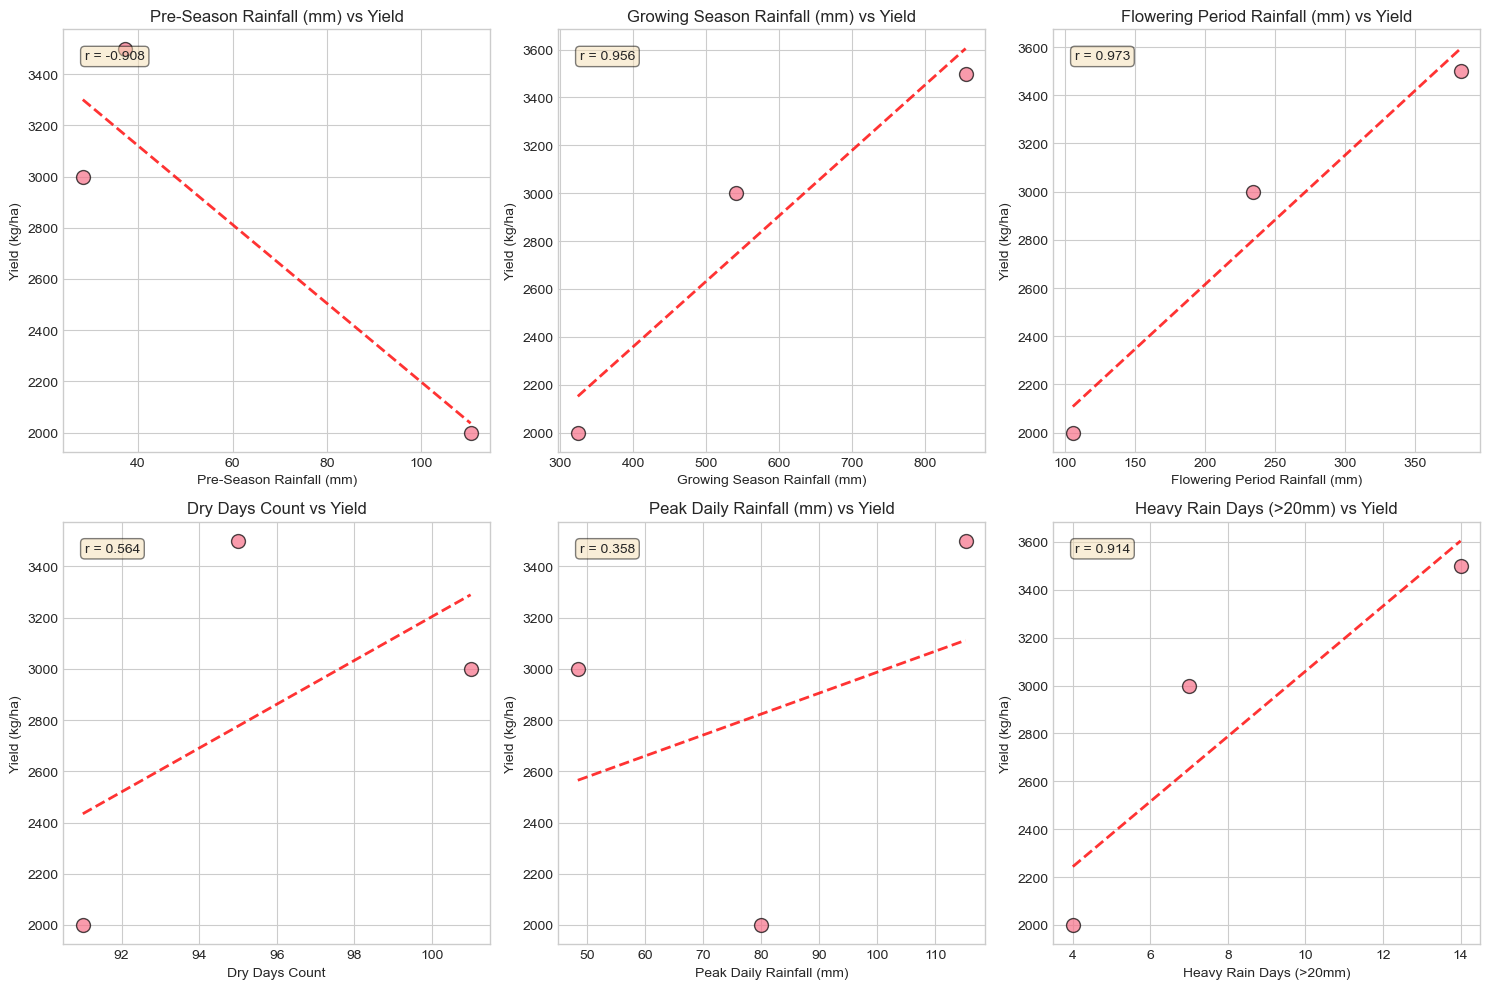

Exploratory analysis complete.
Feature matrix shape: (3, 9)
Target vector shape: (3,)
Small dataset (N=3): Training on all data, evaluating on training set

Training Performance:
  RMSE: 296.21 kg/ha
  MAE:  271.67 kg/ha
  R²:   0.774


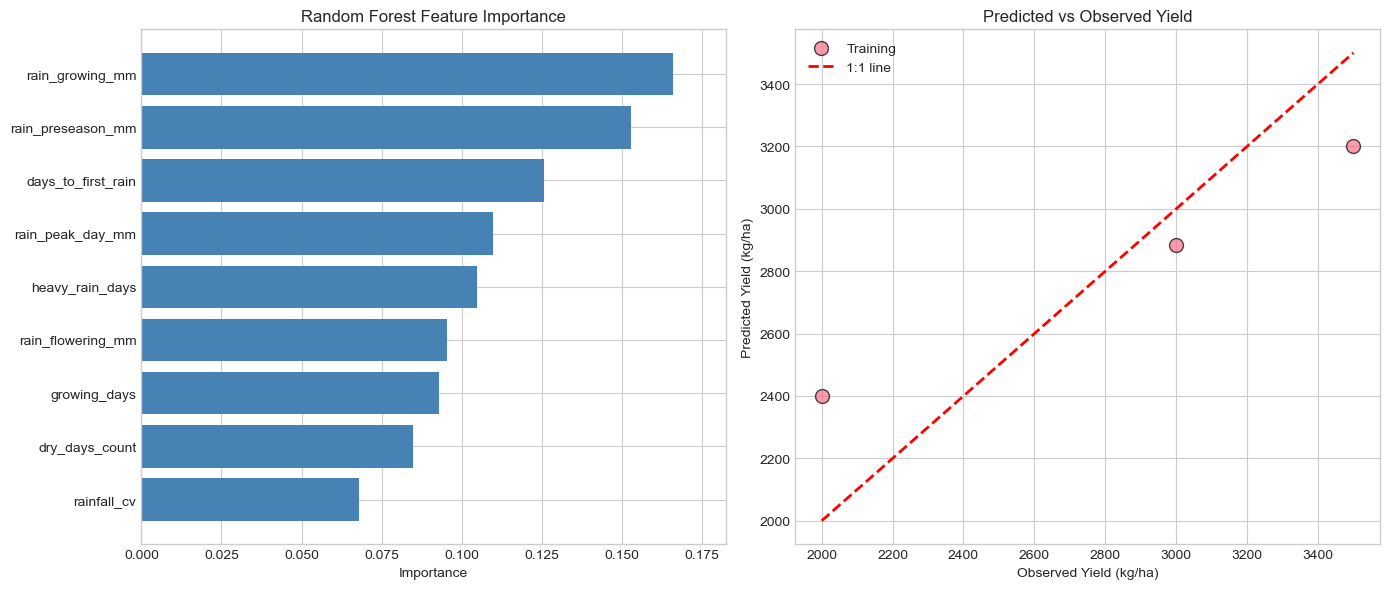


Feature importance ranking:
              feature  importance
1     rain_growing_mm    0.165966
0   rain_preseason_mm    0.152941
7  days_to_first_rain    0.125630
3    rain_peak_day_mm    0.109664
5     heavy_rain_days    0.104622
2   rain_flowering_mm    0.095378
8        growing_days    0.092857
4      dry_days_count    0.084874
6         rainfall_cv    0.068067
ANALYSIS COMPLETE

Results saved to:
  - results/model_results.json
  - results/engineered_features.csv
  - figures/*.png

Key findings:
  - Analyzed 3 plot-seasons
  - Most important feature: rain_growing_mm
  - Training RMSE: 296.21 kg/ha
  - Test evaluation: N/A (train on all data due to small sample)

Next steps:
  1. Expand to more plots and seasons
  2. Integrate MODIS NDVI for vegetation phenology
  3. Test XGBoost and neural network models
  4. Implement cross-season validation


In [5]:
# ============================================================================
# KENYA SMALLHOLDER MAIZE YIELD PREDICTION
# Clement Ongera Nyangoya
# April-May 2026
#
# Predicts maize yield from CHIRPS rainfall data using Random Forest.
# Designed for small sample sizes (pilot study, 1-5 plots, 2-5 seasons).
# ============================================================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 60)

# ============================================================================
# 1. LOAD YIELD RECORDS
# ============================================================================

def load_yield_records(filepath):
    """
    Load farmer-reported yield data.
    Expected columns: plot_id, latitude, longitude, season, planting_date,
                      harvest_date, yield_kg, area_m2, notes
    """
    df = pd.read_csv(filepath)
    
    # Parse dates
    df['planting_date'] = pd.to_datetime(df['planting_date'])
    df['harvest_date'] = pd.to_datetime(df['harvest_date'])
    
    # Calculate yield per hectare
    df['yield_kg_ha'] = (df['yield_kg'] / df['area_m2']) * 10000
    
    # Calculate growing season length
    df['growing_days'] = (df['harvest_date'] - df['planting_date']).dt.days
    
    # Create unique plot-season ID
    df['plot_season_id'] = df['plot_id'] + '_' + df['season']
    
    return df

# Load your data
yield_df = load_yield_records('yield_records.csv')

print(f"Yield records loaded: {len(yield_df)} plot-seasons")
print(f"\nPlots: {yield_df['plot_id'].nunique()}")
print(f"Seasons: {yield_df['season'].nunique()}")
print(f"Date range: {yield_df['planting_date'].min().date()} to {yield_df['harvest_date'].max().date()}")
print(f"\nYield statistics (kg/ha):")
print(yield_df['yield_kg_ha'].describe())
print(f"\nFirst few records:")
yield_df[['plot_id', 'season', 'planting_date', 'harvest_date', 'yield_kg_ha', 'growing_days']]

# ============================================================================
# 2. LOAD CHIRPS RAINFALL DATA
# ============================================================================

def load_chirps_data(filepath):
    """
    Load CHIRPS daily rainfall extracted from Google Earth Engine or Climate Engine.
    Expected columns: plot_id, date, rainfall_mm (or latitude, longitude, date, rainfall_mm)
    """
    df = pd.read_csv(filepath)
    
    # Parse date
    df['date'] = pd.to_datetime(df['date'])
    
    # Ensure rainfall is numeric
    df['rainfall_mm'] = pd.to_numeric(df['rainfall_mm'], errors='coerce')
    
    return df

# Load rainfall data
rain_df = load_chirps_data('chirps_rainfall.csv')

print(f"Rainfall records loaded: {len(rain_df)} daily observations")
print(f"\nDate range: {rain_df['date'].min().date()} to {rain_df['date'].max().date()}")
print(f"Plots covered: {rain_df['plot_id'].nunique()}")
print(f"\nRainfall statistics (mm):")
print(rain_df['rainfall_mm'].describe())
print(f"\nFirst few records:")
rain_df.head()


# ============================================================================
# 3. FEATURE ENGINEERING: RAINFALL METRICS PER PLOT-SEASON
# ============================================================================

def compute_rainfall_features(yield_df, rain_df):
    """
    Compute agronomically relevant rainfall features for each plot-season.
    """
    features = []
    
    for _, row in yield_df.iterrows():
        plot_id = row['plot_id']
        season = row['season']
        planting = row['planting_date']
        harvest = row['harvest_date']
        
        # Filter rainfall for this plot and time window
        # Window: 30 days before planting to harvest
        window_start = planting - timedelta(days=30)
        plot_rain = rain_df[
            (rain_df['plot_id'] == plot_id) &
            (rain_df['date'] >= window_start) &
            (rain_df['date'] <= harvest)
        ].copy()
        
        if len(plot_rain) == 0:
            print(f"WARNING: No rainfall data for {plot_id} {season}")
            continue
        
        # 1. Pre-season rainfall (30 days before planting)
        pre_season = plot_rain[plot_rain['date'] < planting]
        rain_preseason = pre_season['rainfall_mm'].sum()
        
        # 2. Growing season rainfall (planting to harvest)
        growing = plot_rain[(plot_rain['date'] >= planting) & (plot_rain['date'] <= harvest)]
        rain_growing = growing['rainfall_mm'].sum()
        
        # 3. Flowering period rainfall (weeks 4-8 after planting)
        flowering_start = planting + timedelta(days=28)
        flowering_end = planting + timedelta(days=56)
        flowering = plot_rain[
            (plot_rain['date'] >= flowering_start) &
            (plot_rain['date'] <= flowering_end)
        ]
        rain_flowering = flowering['rainfall_mm'].sum()
        
        # 4. Peak daily rainfall
        rain_peak_day = plot_rain['rainfall_mm'].max()
        
        # 5. Number of dry days (< 1mm during growing season)
        dry_days = (growing['rainfall_mm'] < 1.0).sum()
        
        # 6. Number of heavy rain days (> 20mm)
        heavy_rain_days = (growing['rainfall_mm'] > 20.0).sum()
        
        # 7. Rainfall distribution (coefficient of variation)
        rain_cv = growing['rainfall_mm'].std() / growing['rainfall_mm'].mean() if growing['rainfall_mm'].mean() > 0 else 0
        
        # 8. First significant rain (first day with > 10mm after planting window)
        sig_rain = plot_rain[plot_rain['rainfall_mm'] > 10.0]
        days_to_first_rain = (sig_rain['date'].min() - planting).days if len(sig_rain) > 0 else np.nan
        
        features.append({
            'plot_season_id': row['plot_season_id'],
            'plot_id': plot_id,
            'season': season,
            'latitude': row['latitude'],
            'longitude': row['longitude'],
            'area_m2': row['area_m2'],
            'growing_days': row['growing_days'],
            'rain_preseason_mm': rain_preseason,
            'rain_growing_mm': rain_growing,
            'rain_flowering_mm': rain_flowering,
            'rain_peak_day_mm': rain_peak_day,
            'dry_days_count': dry_days,
            'heavy_rain_days': heavy_rain_days,
            'rainfall_cv': rain_cv,
            'days_to_first_rain': days_to_first_rain,
            'yield_kg_ha': row['yield_kg_ha']  # Target variable
        })
    
    return pd.DataFrame(features)

feature_df = compute_rainfall_features(yield_df, rain_df)

print(f"Features computed for {len(feature_df)} plot-seasons")
print(f"\nFeature columns: {list(feature_df.columns)}")
print(f"\nFirst few rows:")
feature_df.head()

# ============================================================================
# 4. EXPLORATORY ANALYSIS: RAINFALL vs YIELD RELATIONSHIPS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# List of features to plot against yield
plot_features = [
    ('rain_preseason_mm', 'Pre-Season Rainfall (mm)'),
    ('rain_growing_mm', 'Growing Season Rainfall (mm)'),
    ('rain_flowering_mm', 'Flowering Period Rainfall (mm)'),
    ('dry_days_count', 'Dry Days Count'),
    ('rain_peak_day_mm', 'Peak Daily Rainfall (mm)'),
    ('heavy_rain_days', 'Heavy Rain Days (>20mm)')
]

for idx, (feature, label) in enumerate(plot_features):
    row, col = idx // 3, idx % 3
    ax = axes[row, col]
    
    if feature in feature_df.columns:
        # Scatter plot
        ax.scatter(feature_df[feature], feature_df['yield_kg_ha'], 
                  s=100, alpha=0.7, edgecolors='black')
        
        # Add trend line if enough data
        if len(feature_df) >= 3:
            z = np.polyfit(feature_df[feature].dropna(), 
                          feature_df.loc[feature_df[feature].notna(), 'yield_kg_ha'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(feature_df[feature].min(), feature_df[feature].max(), 100)
            ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        ax.set_xlabel(label)
        ax.set_ylabel('Yield (kg/ha)')
        ax.set_title(f'{label} vs Yield')
        
        # Add correlation if computable
        if len(feature_df) >= 3:
            corr = feature_df[[feature, 'yield_kg_ha']].corr().iloc[0, 1]
            ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/rainfall_yield_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print("Exploratory analysis complete.")

# ============================================================================
# 5. MODEL TRAINING: RANDOM FOREST
# ============================================================================

# Define features and target
feature_cols = [
    'rain_preseason_mm', 'rain_growing_mm', 'rain_flowering_mm',
    'rain_peak_day_mm', 'dry_days_count', 'heavy_rain_days',
    'rainfall_cv', 'days_to_first_rain', 'growing_days'
]

# Handle missing values
X = feature_df[feature_cols].fillna(feature_df[feature_cols].median())
y = feature_df['yield_kg_ha']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# For very small datasets (N < 5), use simple split
# For N >= 5, use train/test split
if len(X) >= 5:
    X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
        X, y, feature_df['plot_season_id'], test_size=0.3, random_state=42
    )
    print(f"Train: {len(X_train)}, Test: {len(X_test)}")
else:
    # For tiny datasets, train on all data and use cross-validation
    X_train, y_train = X, y
    X_test, y_test = X, y  # Will show training performance
    id_train = feature_df['plot_season_id']
    id_test = feature_df['plot_season_id']
    print(f"Small dataset (N={len(X)}): Training on all data, evaluating on training set")

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,  # Conservative to avoid overfitting on small data
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rf.fit(X_train, y_train)

# Predictions
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Evaluation
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(y_true) > 2 else np.nan
    
    print(f"\n{dataset_name} Performance:")
    print(f"  RMSE: {rmse:.2f} kg/ha")
    print(f"  MAE:  {mae:.2f} kg/ha")
    print(f"  R²:   {r2:.3f}" if not np.isnan(r2) else "  R²:   N/A (insufficient data)")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

train_metrics = evaluate_model(y_train, y_pred_train, "Training")
test_metrics = evaluate_model(y_test, y_pred_test, "Test") if len(X) >= 5 else None

# ============================================================================
# 6. FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(importance['feature'], importance['importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlim(0, importance['importance'].max() * 1.1)

# Predicted vs Observed
axes[1].scatter(y_train, y_pred_train, s=100, alpha=0.7, label='Training', edgecolors='black')
if test_metrics:
    axes[1].scatter(y_test, y_pred_test, s=100, alpha=0.7, label='Test', 
                   marker='s', edgecolors='black')

# 1:1 line
min_val = min(y.min(), y_pred_train.min())
max_val = max(y.max(), y_pred_train.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 line')

axes[1].set_xlabel('Observed Yield (kg/ha)')
axes[1].set_ylabel('Predicted Yield (kg/ha)')
axes[1].set_title('Predicted vs Observed Yield')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature importance ranking:")
print(importance.sort_values('importance', ascending=False))


# ============================================================================
# 7. SUMMARY AND EXPORT
# ============================================================================

# Create detailed results
results = {
    'project': 'Kenya Smallholder Maize Yield Prediction',
    'author': 'Clement Ongera Nyangoya',
    'date': datetime.now().strftime('%Y-%m-%d'),
    'data': {
        'plot_seasons': len(feature_df),
        'plots': feature_df['plot_id'].nunique(),
        'seasons': feature_df['season'].nunique(),
        'date_range': {
            'start': str(yield_df['planting_date'].min().date()),
            'end': str(yield_df['harvest_date'].max().date())
        }
    },
    'features': {
        'used': feature_cols,
        'most_important': importance.sort_values('importance', ascending=False).iloc[0]['feature']
    },
    'model': {
        'type': 'RandomForestRegressor',
        'n_estimators': 100,
        'max_depth': 3
    },
    'performance': {
        'training': train_metrics,
        'test': test_metrics if test_metrics else 'N/A (insufficient data for split)'
    },
    'limitations': [
        'Small sample size (pilot study)',
        'Farmer-reported yield estimates (not formally weighed)',
        'CHIRPS rainfall estimates (5.5km resolution, not ground measurements)',
        'Single plot or limited spatial coverage',
        'No soil nutrient, pest, or management data'
    ]
}

# Save to JSON
with open('results/model_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Save features to CSV for inspection
feature_df.to_csv('results/engineered_features.csv', index=False)

print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)
print(f"\nResults saved to:")
print(f"  - results/model_results.json")
print(f"  - results/engineered_features.csv")
print(f"  - figures/*.png")

print(f"\nKey findings:")
print(f"  - Analyzed {len(feature_df)} plot-seasons")
print(f"  - Most important feature: {results['features']['most_important']}")
print(f"  - Training RMSE: {train_metrics['rmse']:.2f} kg/ha")
if test_metrics:
    print(f"  - Test RMSE: {test_metrics['rmse']:.2f} kg/ha")
else:
    print(f"  - Test evaluation: N/A (train on all data due to small sample)")

print(f"\nNext steps:")
print(f"  1. Expand to more plots and seasons")
print(f"  2. Integrate MODIS NDVI for vegetation phenology")
print(f"  3. Test XGBoost and neural network models")
print(f"  4. Implement cross-season validation")